In [1]:
from __future__ import annotations

from operator import add
from typing import TypedDict,Annotated,List,Literal

from pydantic import BaseModel,Field
from langgraph.graph import StateGraph,START,END, add_messages
from langgraph.types import Send

from pathlib import Path

import re
import unicodedata
from langchain_community.document_loaders import WebBaseLoader,PyPDFLoader

from prompts import *

from langchain_openai import ChatOpenAI
from langchain.messages import SystemMessage,HumanMessage

from langchain_tavily import TavilySearch

from dotenv import load_dotenv

from openai import AsyncOpenAI
import base64

import asyncio

load_dotenv()

True

`from __future__ import annotations` does not throw error when you instantiate a class that is not yet defined. It does not perform validations (accross type hinting) at runtime rather store them as strings and perform them later. 

Example: In the below example there are two classes referencing each other. When we are creating the class profile the User has not been created but yet used in the during the creation of profile.
```
from __future__ import annotations
class profile:
    def __init__(self,user: User):
        self.user = user
        
class User:
    def __init__(self,profile: Profile):
        self.profile = Profile
```


About the project: We will take the `state['topic']` from the user, according to which orchestrator will create a plan. This plan will contain some N numbers of tasks which will be executed by N number of worker nodes each creating a section (task) of the blog. The output of each worker is stored inside the section. These individual sections are then combined by a reducer and presented as .md file.

`...` inside Field means mandatory field; if not present, it is still mandatory.

default uses the same exact object directly but default_factory calls a function to create a new object every time.

If we do `tags: list = []`, the same mutable list can be shared unexpectedly. By using `tags :List[str] = Field(default_factory=list)`, Now every instance gets a fresh new list. 

default is for immutable values like (0, "hello", True) but default_factory is for mutable values (list, dict, set) or dynamically generated values (uuid, timestamps)

List from typing is only a type hint. It describes types for static checking and validation, but it is not meant to create objects. but on the other hand list is the actual Python constructor that will create a new empty list each time.

default_factory or default needs a real callable constructor that creates an object at runtime.

In [2]:
class Task(BaseModel):
    id:int = Field("Task ID")
    title: str
    
    goal:str = Field(
        description="a sentence describing what the reader should be able to understand after reading this section."
        )
    
    bullets: List[str] = Field(
        min_length=3,
        max_length=6,
        description="3-6 concrete non-overlapping subpoints to cover in this section."
    )
    
    target_words:int = Field(...,description="Target word count for this section (120-450)", ge=120, le=450)
    tags :List[str] = Field(default_factory=list)
    requires_citation: bool = False
    requires_research: bool = False
    requires_code:bool = False

class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]
    audience: str = Field(description="type of audience for whom this blog is for.")
    tone:str = Field(description=" Tone of writing (eg. detailed, practical, formal, crisp)")
    constraints:List[str] = Field(default_factory=list)

class RouterDecision(BaseModel):
    needs_research : bool = Field(description="Whether or not the topic requires Internet research. If yes return True else False")
    mode: Literal["closed_book","hybrid","open_book"]
    search_queries : List[str] = Field(description="List of 3-8 useful search queries")

class SearchItem(BaseModel):
    title:str = Field(description="tilte of Search Item")
    url:str = Field(description="URL given from tavily")
    content:str = Field(description="Actual Content")

class SearchPack(BaseModel):
    search_results : List[SearchItem] = Field(default_factory=list)

class ImageSpec(BaseModel):
    name:str = Field(...,description="Name of the image like \"Traditional_RAG_VS_Corrective_RAG\"")
    alt_text:str = Field(description="Alt text for the image")
    caption:str = Field(description="Caption for the image")
    prompt:str = Field(description="Instructions given to the Image model to generate the desired image. Has to be specific, not generic")
    size:Literal["1024x1024","1024x1536","1536x1024"] = "1024x1024"
    placeholder:str = Field(...,description="Example: [[IMAGE_1]], [[IMAGE_2]] ")

class ImageOutputPack(BaseModel):
    images:List[ImageSpec] = Field(default_factory=list, description="List of images")
    md_with_placeholders:str = Field(description="Markdown along with Image placeholders")
    need_images:bool = Field(description="if the blog need images, return True else False")

class urlPack(BaseModel):
    urls:List[str] = Field(description="List of urls for web scraping",default_factory=list)

class WebPage(BaseModel):
    url:str
    content:str

class WebPagePack(BaseModel):
    webpages: List[WebPage] = Field(default_factory=list,description="List of webpages")


In [3]:
class State(TypedDict):
    topic: str 
    mode : Literal["closed_book","hybrid","open_book"] # Based on which we continue the flow
    plan : Plan
    
    search_queries: List[str]
    needs_research: bool
    search_results: SearchPack

    sections : Annotated[List[str],add]

    merged_md:str
    need_images:bool
    images: List[ImageSpec]
    md_with_placeholders:str

    scraped_webpages: List[WebPage]

    final: str

`operator.add` is a reducer function that will concatenate the result(str) from each worker inside the list called sections. 

In [4]:
model = ChatOpenAI(model = "gpt-4.1-mini-2025-04-14")

In [5]:
# node that will tell wheather we need to search the internet or not 
async def router(state: State) -> dict:
    try:
        topic = state["topic"]
        if not topic:
            raise ValueError("State missing 'topic'")
        decision: RouterDecision = await model.with_structured_output(RouterDecision).ainvoke([
            SystemMessage(content=ROUTER_PROMPT.format(topic= topic))
        ])

    except Exception as e:
         raise RuntimeError("LLM failed to output the routing decision") from e

    if len(decision.search_queries) > 8:
        raise ValueError(
            "Search Queries cannot be greater than 8."
        )
        
    return {"search_queries":decision.search_queries,"needs_research":decision.needs_research,"mode":decision.mode}


def route_next(state:State):
    return "research" if state["needs_research"] else "orchestrator"
    

In [6]:
# from langchain_tavily import TavilySearch

# tool = TavilySearch(max_results= 2)
# res = tool.invoke(input= "Who is the lead in the IPL 2026? Who are the runnerups?")
# print(res)

In [7]:
# res['results']

In [8]:
async def _tavily_search(query:str, max_results: int = 2)-> List[dict]:
    
    tool = TavilySearch(max_results= max_results)
    try:
        response = await tool.ainvoke(input = query)
    except Exception as e:
        raise RuntimeError("TavilySearch failed") from e

    # URL, Content, Title, Images, Answer
    results = []
    for res in response.get('results',[]):
        results.append({
            "title":res.get('title') or "",
            "url": res.get('url') or "",
            'content':res.get('content') or ""
        })
    return results

`async def` only creates a coroutine obeject(which is a suspended task that can be executed later). When you actually await the the coroutines the execution starts. You can store the coroutines in a list and and `await async.gather(*stored_coroutines)` to run them concurretly.

In [9]:
def _clean_text(text: str) -> str:
    # Normalize unicode characters
    text = unicodedata.normalize("NFKC", text)

    # Remove escape sequences / control chars
    text = text.replace("\n", " ")
    text = text.replace("\r", " ")
    text = text.replace("\t", " ")

    # Remove non-printable characters
    text = re.sub(r"[\x00-\x1F\x7F-\x9F]", "", text)

    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text)

    # Remove extra spaces before punctuation
    text = re.sub(r"\s([?.!,;:])", r"\1", text)

    return text.strip()


In [ ]:
async def searchInternet(state:State) -> dict:
    queries = state['search_queries'] # Can be empty
    if not queries:
        return {"search_results":[]}

    tasks = [_tavily_search(query) for query in queries]
    raw_results = await asyncio.gather(*tasks) # output [[S1,S2],[S3,S4]]

    # Flatten results
    raw_results = [
            item
            for result in raw_results
            for item in result
        ] 
    
    try:
        search_pack : SearchPack = await model.with_structured_output(SearchPack).ainvoke(
            [
                SystemMessage(content = RESEARCH_PROMPT),
                HumanMessage(content=f"Raw Results: \n {raw_results}")
            ]
        )
    except Exception as e:
        raise RuntimeError("LLM failed to process the raw search results.") from e

    # Deduplicate SearchItem by URL
    deduplicate = {}
    for search_result in search_pack.search_results:
        if search_result.url:
            deduplicate[search_result.url] = search_result
            
    return {'search_results': list(deduplicate.values())}

async def _scrape_url(url:str) -> WebPage:
    if url.endswith('.pdf'):
        loader = PyPDFLoader(file_path=url,mode='single',)
    else:
        loader = WebBaseLoader(url)
    try:
        docs = [doc async for doc in loader.alazy_load()]
    except Exception as e:
        raise RuntimeError(f"{loader} failed") from e
    
    raw_text = _clean_text(docs[0].page_content)
    return WebPage(url= url,content=raw_text)

async def scrape_web(state:State) -> dict:
    search_results = state['search_results']
    topic = state['topic']

    try:
        url_pack : urlPack = await model.with_structured_output(urlPack).ainvoke(
            [
                SystemMessage(content=SCRAPE_URLS_PROMPT),
                HumanMessage(content=f"topic: {topic}\n URLs: \n {[search_result.model_dump() for search_result in search_results]}")
            ]
        )
    except Exception as e:
        raise RuntimeError("LLM failed to scrape the given URLs.") from e

    if len(url_pack.urls) > 2:
        raise ValueError("Atmost 2 URLs can be scraped.")
    
    tasks = [_scrape_url(url) for url in url_pack.urls]
    scraped_webpages = await asyncio.gather(*tasks)

    return {"scraped_webpages":scraped_webpages}

async def summarise_scraped_pages(state:State) -> dict:
    webpages = state['scraped_webpages']
    webpages_content = ""
    for webpage in webpages:
        webpages_content += f"\n\nURL: {webpage.url} \n Content: \n {webpage.content}" 

    try:
        webpage_pack: WebPagePack = await model.with_structured_output(WebPagePack).ainvoke(
            [
                SystemMessage(content= REFINE_WEBPAGE_CONTENT),
                HumanMessage(content = f"Raw Website content: \n{webpages_content}")
            ]
        )
    except Exception as e:
        raise RuntimeError("LLM failed to summarise the webpages.") from e

    return {"scraped_webpages":webpage_pack.webpages}

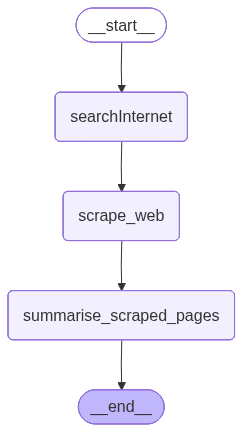

In [11]:
research_subgraph = StateGraph(State)
research_subgraph.add_node(node= "searchInternet", action=searchInternet)
research_subgraph.add_node("scrape_web", scrape_web)
research_subgraph.add_node("summarise_scraped_pages", summarise_scraped_pages)
research_subgraph.add_edge(START,"searchInternet")
research_subgraph.add_edge("searchInternet","scrape_web")
research_subgraph.add_edge("scrape_web","summarise_scraped_pages")
research_subgraph.add_edge("summarise_scraped_pages",END)
research = research_subgraph.compile()
research


In [12]:
async def orchestrator(state: State) -> dict:
    mode = state.get("mode","closed_book")
    search_results = state.get('search_results',[])[:20] # Can be empty
    webpages = state.get('scraped_webpages',[]) # Can be empty

    try:
        plan = await model.with_structured_output(Plan).ainvoke(
            [
                SystemMessage(content = ORCHESTRATOR_PROMPT),
                HumanMessage(content = f"""
                            topic = {state['topic']}\n
                            Mode: {mode}\n
                            Search Results (ONLY FOR RECENT CLAIMS; Can be empty)\n
                            {[search_result.model_dump() for search_result in search_results]}\n\n
                            Scraped Web Pages Content (ONLY FOR RECENT CLAIMS; Can be Empty): {[webpage.model_dump() for webpage in webpages ]}
                            """),
            ]
        )
    except Exception as e:
        raise RuntimeError("LLM failed to create a plan") from e
    
    return {"plan":plan}

Now, we have tasks defined inside the our plan, we need to spawn the worker nodes which we can do using the Send function. fanoutWorkers is only a helper function to spawn worker nodes. It is not actually a node itself.

In [13]:
def fanoutWorkers(state: State) -> List:
    sends = []
    for task in state['plan'].tasks:
        sends.append(Send(
            "worker",arg= {
                "task":task.model_dump(), 
                "plan": state['plan'].model_dump(),
                "topic":state['topic'],
                "mode":state["mode"],
                "search_results": [search_result.model_dump() for search_result in state.get("search_results",[])[:20]],
                "webpages": [webpage.model_dump() for webpage in state.get('scraped_webpages',[])]
                }
            )
        )
    return sends

`.model_dump()` converts the pydantic object into dictionary. .dict() method is deprecated. For SearchItem it will be `{url: "https://example.com", "title": "Some title", "content": "Some content"}`

`*` unpacks the elemnts inside the list and send them as individual parameters. In a function parameters you can have `*args` that represents any amount of arguments can be passed to the function. You can also combine two or more lists by unpacking them inside a list.
```
def my_sum(*args):
    res = 0
    for param in args:
        res += param
    return res
    
a = [1,2,3]
b = [5,6,7]    
print(my_sum(*a)) # Output 6
c = [*a,'test',*b] # Output [1,2,3,'test',5,6,7]

6
[1, 2, 3, 'test', 5, 6, 7]
``` 

** unpacks the values inside the dictionary and send them as keyword arguments. In a function parameters you can have `**kwargs` that represent any number of keyword argument can be passed to the function. You can also combine two or more dicts by unpacking them inside a dictionary.

```
def print_args(**kwargs):
    for k,v in kwargs.items():
        print(f"Parameter Name: {k} Paramerter Value {v}")
        
a = {"a":1,"b":2,"c":5,"d":9}
b = {"e":4,"f":7}
print_args(**a)

c = {**a, **b} # 
print(c)

Parameter Name: a Paramerter Value 1
Parameter Name: b Paramerter Value 2
Parameter Name: c Paramerter Value 5
Parameter Name: d Paramerter Value 9
{'a': 1, 'b': 2, 'c': 5, 'd': 9, 'e': 4, 'f': 7}
'''


In [14]:
async def worker(payload:dict)-> dict:

    task= Task(**payload['task'])
    plan = Plan(**payload['plan'])
    search_results = [SearchItem(**sr) for sr in payload.get("search_results",[])]
    webpages = [WebPage(**webpage) for webpage in payload.get("webpages",[])]
    
    topic = payload['topic']
    mode = payload.get("mode","closed_book")

    bullet_parts = []
    for bullet in task.bullets:
        bullet_parts.append(f"\n-{bullet}")

    bullets = "\n\n".join(bullet_parts)

    search_parts = []

    for sr in search_results[:20]:
        if sr.content:
            search_parts.append(
                f"{sr.title} | {sr.url}\n{sr.content}"
            )

    search_text = "\n\n".join(search_parts)

    webpage_parts = []

    for page in webpages:
        if page.content:
            webpage_parts.append(
                f"URL: {page.url}\nContent:\n{page.content}"
            )

    webpage_text = "\n\n".join(webpage_parts)


    try:
        # Await the whole AIMessage and then perform content.strip()
        section_md = (await model.ainvoke(
            [
                SystemMessage(content =  WORKER_PROMPT),
                HumanMessage(
                    content = (
                        
                        f"Blog Title: {plan.blog_title}\n"
                        f"Topic: {topic}\n"
                        f"Section Title:{task.title}\n"
                        f"Goal: {task.goal}\n"
                        f"Constraints: {plan.constraints}\n"
                        f"Type of Audience: {plan.audience}\n"
                        f"Tone of writing: {plan.tone}\n"
                        f"Mode: {mode}\n"
                        f"Target Words: {task.target_words}\n"
                        f"Tags: {task.tags}\n"
                        f"Citation Required: {task.requires_citation}\n" 
                        f"Requires Research: {task.requires_research}\n"
                        f"Requires Code:{task.requires_code}\n"
                        f"Bullets: {bullets}\n"
                        f"Search Results (ONLY Use the URLs when citating):\n{search_text}\n"
                        f"Web Page Results: \n\n {webpage_text}\n"
                    )
                )
            ]
        )).content.strip()

    except Exception as e:
        raise RuntimeError(f"Worker node failed; Task ID:{task.id} ") from e

    return {"sections":[(task.id,section_md)]}

In [15]:

async def create_image(prompt:str, image_name:str,size:Literal["1024x1024","1024x1536","1536x1024"]):

    client = AsyncOpenAI()
    try:
        result = await client.images.generate(
            model="gpt-image-2",
            prompt=prompt,
            size=size,
            output_format="png",
            quality="low",
            background="auto",
            n=1
        )
    except Exception as e:
        raise RuntimeError("LLM failed to create an image.") from e

    image_base64 = result.data[0].b64_json
    image_bytes = base64.b64decode(image_base64)

    output_dir = Path("images/")
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / f"{image_name}.png"

    # Save the image to a file
    try:
        await asyncio.to_thread(output_path.write_bytes, image_bytes)
    except Exception as e:
        raise RuntimeError("Failed to save the image") from e
    

In [16]:
def merge_content(state:State) -> dict:
    title = state["plan"].blog_title
    body = ""
    for _,section in sorted(state["sections"],key=lambda x:x[0]):
        body += f"\n\n{section}"

    merged_md = f"# {title}\n\n{body}\n"
    return {"merged_md":merged_md}

async def generate_placeholders(state:State) -> dict:
    try:
        imageOutputPack:ImageOutputPack = await model.with_structured_output(ImageOutputPack).ainvoke(
            [
                SystemMessage(content=CREATE_PLACEHOLDERS),
                HumanMessage(content=f"Blog: \n {state['merged_md']}")
            ]
        )
    except Exception as e:
        raise RuntimeError("Failed to get the Image decision.") from e

    if imageOutputPack.need_images:
        return {"md_with_placeholders":imageOutputPack.md_with_placeholders, "images":imageOutputPack.images, "need_images":imageOutputPack.need_images}

    return {"need_images":imageOutputPack.need_images, "images":[],"md_with_placeholders":state['merged_md']}


def fanoutImages(state:State) -> List:
    images: List[ImageSpec] = state['images']
    sends = []
    if len(images) > 2:
        raise ValueError("Number of images cannot be greater than 2")
    
    if state['need_images']:
        for image in images:
            sends.append(
                Send(node="generate_image",arg={
                    "image": image,
                })
            )
    return sends

In [17]:
def get_image_path(name:str) ->Path:
    return Path("images/") / f"{name}.png"

async def generate_image(payload:dict)-> dict:
    image:ImageSpec = payload['image']
    image_file_path = get_image_path(name = image.name)
    if image.prompt and image.name and not image_file_path.exists():
        try:
            await create_image(prompt=image.prompt, image_name=image.name,size=image.size)
        except Exception as e:
            raise RuntimeError("Failed to create an Image.") from e
            
    return {}

In [18]:
def create_final_markdown(final,title):
    if final:
        safe_title = re.sub(r'[^a-zA-Z0-9_-]', '_', title.lower())
        output_dir = Path("test_blogs")
        output_dir.mkdir(parents=True, exist_ok=True)

        output_path = output_dir / f"{safe_title}.md"
        output_path.write_text(final, encoding="utf-8")
    else:
        raise ValueError("Nothing to write inside the Markdown file.")

def formatCreateMD(state:State):
    images:List[ImageSpec] = state['images']
    final = state["md_with_placeholders"]
    if state['need_images']:
        for image in images:
            image_file_path = get_image_path(name = image.name)
            if image_file_path.exists():
                final= final.replace(f"{image.placeholder}",f"![{image.alt_text}](../{image_file_path.as_posix()})\n*{image.caption}*")
    create_final_markdown(final= final, title=state['plan'].blog_title)
    return {"final":final}


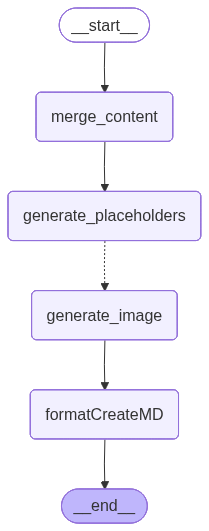

In [19]:
reducer_graph = StateGraph(State)
reducer_graph.add_node("merge_content",merge_content)
reducer_graph.add_node("generate_placeholders",generate_placeholders)
reducer_graph.add_node("generate_image",generate_image)
reducer_graph.add_node("formatCreateMD",formatCreateMD)
reducer_graph.add_edge(START,"merge_content")
reducer_graph.add_edge("merge_content","generate_placeholders")
reducer_graph.add_conditional_edges("generate_placeholders",fanoutImages,["generate_image"])
reducer_graph.add_edge("generate_image","formatCreateMD")
reducer_graph.add_edge("formatCreateMD",END)

reducer = reducer_graph.compile()
reducer

Main thing is the code to create an image is executed from inside the main.py (inside Blog Agent) but when you are creating the markdown inside the test_blogs; the images path should be from Blog Agent/images, currently it is from test_blogs hence add .. at the begginning of the path. Also insdie formatCreateMD when we are checking if the path of the image exists or not. We are checking from the main.py which is inside Blog Agent, hence no .. there.

In [20]:
builder = StateGraph(State)
builder.add_node("router",router)
builder.add_node("research",research)
builder.add_node("orchestrator",action = orchestrator) # Name, fucntion or runnable this node will run
builder.add_node("worker",worker)
builder.add_node("reducer",reducer)

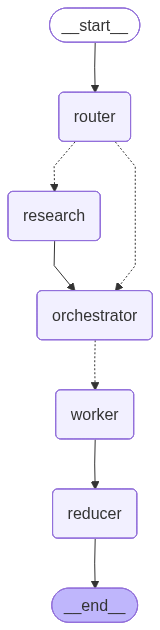

In [21]:
builder.add_edge(START,"router")
builder.add_conditional_edges("router",route_next,path_map={"research":"research","orchestrator":"orchestrator"})
builder.add_edge("research","orchestrator")
builder.add_conditional_edges("orchestrator",fanoutWorkers,["worker"]) # orchestrator -> fanoutWorkers -> List of worker nodes
builder.add_edge("worker","reducer")
builder.add_edge("reducer",END)

graph = builder.compile()
graph


In [25]:
response = await graph.ainvoke({"topic":"Cloud Computing: A paradigm shift towards advancement or limited ownership in 2026"})

Fetching pages: 100%|##########| 1/1 [00:03<00:00,  3.84s/it]


In [ ]:
response